# Demographic Analysis by Cluster

**Purpose:** Profile each lifecycle cluster (V11 HDBSCAN) using developer demographic data, then export summaries for the Recommendations team.

---

## Setup Requirements

### Parquet Files to Download
Obtain these two files from the shared `toexport_clusters/` folder and place them inside:
```
Spring2026_IndustryProject/toexport_clusters/
```

| File | Why You Need It |
|---|---|
| `dev_lifecycle_cluster_membership_v11_final.parquet` | Core table — maps every developer to their cluster, stratum, and adoption direction |
| `dev_lifecycle_cluster_membership_v11_profile_summary.parquet` | Cluster-level behavioral summary — used to add context alongside demographics |

The demographic data (`dev_contact` and `dev_contact_supplement`) is already in your local `Data/` folder — no download needed.

---

Install missing packages if needed:
```bash
pip install duckdb pandas matplotlib seaborn openpyxl
```

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
DB_PATH        = "developer_project.duckdb"
PARQUET_DIR    = Path("toexport_clusters")
DATA_DIR       = Path("Data")
OUTPUT_DIR     = Path("demographic_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Required parquet files ─────────────────────────────────────────────────────
REQUIRED_PARQUETS = [
    "dev_lifecycle_cluster_membership_v11_final",
    "dev_lifecycle_cluster_membership_v11_profile_summary",
]

missing = [f for f in REQUIRED_PARQUETS if not (PARQUET_DIR / f"{f}.parquet").exists()]
if missing:
    raise FileNotFoundError(
        f"Missing parquet files in {PARQUET_DIR}/:\n  " + "\n  ".join(f + ".parquet" for f in missing)
        + "\n\nSee the Setup Requirements section at the top of this notebook."
    )

print("All required parquet files found.")

All required parquet files found.


## 1. Load Data into DuckDB

In [2]:
con = duckdb.connect(DB_PATH)

# ── Load cluster parquet files ─────────────────────────────────────────────────
for name in REQUIRED_PARQUETS:
    path = (PARQUET_DIR / f"{name}.parquet").as_posix()
    con.execute(f"CREATE OR REPLACE TABLE {name} AS SELECT * FROM read_parquet('{path}')")
    n = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f"Loaded {name}: {n:,} rows")

# ── Load demographic CSVs ─────────────────────────────────────────────────────
contact_path = DATA_DIR / "DEVPM_8674_Cal_Poly_Export_dev_contact.csv"
supplement_path = DATA_DIR / "DEVPM_8674_Cal_Poly_Export_dev_contact_supplement.csv"

con.execute(f"""
    CREATE OR REPLACE TABLE dev_contact_raw AS
    SELECT * FROM read_csv_auto('{contact_path.as_posix()}', header=true, all_varchar=true)
""")
con.execute(f"""
    CREATE OR REPLACE TABLE dev_contact_supplement_raw AS
    SELECT * FROM read_csv_auto('{supplement_path.as_posix()}', header=true, all_varchar=true)
""")

# Stack both contact files — supplement covers additional developer IDs
con.execute("""
    CREATE OR REPLACE TABLE dev_demographics AS
    SELECT
        CAST(developer_id AS VARCHAR)          AS developer_id,
        country,
        region,
        sub_region,
        territory,
        organization_english_name              AS organization,
        development_areas,
        industry_segment_vertical              AS industry_vertical,
        sub_industry_segment_vertical          AS sub_industry,
        fields_of_interest,
        program_application_source,
        account_type,
        wwfo_category,
        wwfo_target_list,
        account_industry_segment,
        account_source,
        first_program_application_date,
        first_activity_date,
        last_activity_date
    FROM dev_contact_raw
    UNION ALL
    SELECT
        CAST(developer_id AS VARCHAR)          AS developer_id,
        country,
        region,
        sub_region,
        territory,
        organization_english_name              AS organization,
        development_areas,
        industry_segment_vertical              AS industry_vertical,
        sub_industry_segment_vertical          AS sub_industry,
        fields_of_interest,
        program_application_source,
        account_type,
        wwfo_category,
        wwfo_target_list,
        account_industry_segment,
        account_source,
        first_program_application_date,
        first_activity_date,
        last_activity_date
    FROM dev_contact_supplement_raw
    QUALIFY ROW_NUMBER() OVER (PARTITION BY developer_id ORDER BY last_activity_date DESC NULLS LAST) = 1
""")

n_demo = con.execute("SELECT COUNT(*) FROM dev_demographics").fetchone()[0]
print(f"Loaded dev_demographics: {n_demo:,} rows (deduplicated)")

Loaded dev_lifecycle_cluster_membership_v11_final: 9,381,508 rows
Loaded dev_lifecycle_cluster_membership_v11_profile_summary: 26 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded dev_demographics: 9,381,490 rows (deduplicated)


## 2. Build the Master Analysis Table

Join cluster membership with demographics. Every developer gets their cluster label + all demographic fields.

In [3]:
con.execute("""
    CREATE OR REPLACE TABLE cluster_demo AS
    SELECT
        c.developer_id,
        c.stratum,
        c.cluster_key,
        c.adoption_direction,
        c.hdbscan_cluster,
        c.cluster_probability,
        c.outlier_score,
        -- Demographics
        d.country,
        d.region,
        d.sub_region,
        d.territory,
        d.organization,
        d.industry_vertical,
        d.sub_industry,
        d.development_areas,
        d.fields_of_interest,
        d.program_application_source,
        d.account_type,
        d.wwfo_category,
        d.wwfo_target_list,
        d.account_industry_segment,
        d.account_source,
        d.first_program_application_date,
        d.first_activity_date,
        d.last_activity_date
    FROM dev_lifecycle_cluster_membership_v11_final c
    LEFT JOIN dev_demographics d
        ON CAST(c.developer_id AS VARCHAR) = d.developer_id
""")

total  = con.execute("SELECT COUNT(*) FROM cluster_demo").fetchone()[0]
matched = con.execute("SELECT COUNT(*) FROM cluster_demo WHERE country IS NOT NULL").fetchone()[0]
print(f"cluster_demo: {total:,} developers total, {matched:,} ({matched/total:.1%}) matched to demographic data")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

cluster_demo: 9,381,508 developers total, 9,378,649 (100.0%) matched to demographic data


## 3. High-Level Cluster Population Summary

In [4]:
cluster_summary = con.execute("""
    SELECT
        stratum,
        cluster_key,
        adoption_direction,
        COUNT(*)                                               AS n_developers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2)    AS pct_of_total,
        ROUND(AVG(cluster_probability), 3)                     AS avg_confidence,
        COUNT(CASE WHEN country IS NOT NULL THEN 1 END)        AS n_with_demographics,
        ROUND(
            COUNT(CASE WHEN country IS NOT NULL THEN 1 END) * 100.0 / COUNT(*), 1
        )                                                      AS demo_match_pct
    FROM cluster_demo
    GROUP BY stratum, cluster_key, adoption_direction
    ORDER BY n_developers DESC
""").fetchdf()

display(cluster_summary)
cluster_summary.to_csv(OUTPUT_DIR / "00_cluster_population_summary.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/00_cluster_population_summary.csv")

,stratum,cluster_key,adoption_direction,n_developers,pct_of_total,avg_confidence,n_with_demographics,demo_match_pct
0,dormant,Dormant_Low_Depth,steady_inactive,2466341,26.29,1.000,2465394,100.0
1,unactivated,unactivated,not_activated,1721230,18.35,1.000,1721163,100.0
2,dormant,Dormant_Former_Builders,steady_inactive,1662813,17.72,1.000,1662005,100.0
3,dormant,Dormant_One_Time_Users,steady_inactive,1175698,12.53,1.000,1175291,100.0
4,at_risk,at_risk_0,at_risk,436295,4.65,0.849,436170,100.0
5,at_risk,at_risk_5,at_risk,365945,3.90,0.818,365856,100.0
6,at_risk,at_risk_2,at_risk,210377,2.24,0.825,210363,100.0
7,at_risk,at_risk_3,at_risk,206907,2.21,0.541,206859,100.0
8,active,active_5,accelerating_or_active,155026,1.65,0.975,155002,100.0
9,at_risk,at_risk_1,at_risk,145077,1.55,1.000,145016,100.0


Saved → demographic_outputs/00_cluster_population_summary.csv


## 4. Geographic Distribution by Cluster

In [5]:
# ── Region breakdown ───────────────────────────────────────────────────────────
region_by_cluster = con.execute("""
    SELECT
        cluster_key,
        stratum,
        COALESCE(region, 'Unknown') AS region,
        COUNT(*) AS n_developers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_key), 2) AS pct_within_cluster
    FROM cluster_demo
    GROUP BY cluster_key, stratum, region
    ORDER BY cluster_key, n_developers DESC
""").fetchdf()

region_by_cluster.to_csv(OUTPUT_DIR / "01_region_by_cluster.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/01_region_by_cluster.csv")
display(region_by_cluster.head(30))

Saved → demographic_outputs/01_region_by_cluster.csv


,cluster_key,stratum,region,n_developers,pct_within_cluster
0,Dormant_Former_Builders,dormant,APAC,895968,53.88
1,Dormant_Former_Builders,dormant,EMEA,437755,26.33
2,Dormant_Former_Builders,dormant,NALA,311781,18.75
3,Dormant_Former_Builders,dormant,null,16501,0.99
4,Dormant_Former_Builders,dormant,Unknown,808,0.05
5,Dormant_Low_Depth,dormant,APAC,1234211,50.04
6,Dormant_Low_Depth,dormant,EMEA,648222,26.28
7,Dormant_Low_Depth,dormant,NALA,536756,21.76
8,Dormant_Low_Depth,dormant,null,46205,1.87
9,Dormant_Low_Depth,dormant,Unknown,947,0.04


In [6]:
# ── Top 10 countries per cluster ───────────────────────────────────────────────
top_countries = con.execute("""
    SELECT
        cluster_key,
        COALESCE(country, 'Unknown') AS country,
        COUNT(*) AS n_developers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_key), 2) AS pct_within_cluster,
        ROW_NUMBER() OVER (PARTITION BY cluster_key ORDER BY COUNT(*) DESC) AS country_rank
    FROM cluster_demo
    GROUP BY cluster_key, country
    QUALIFY country_rank <= 10
    ORDER BY cluster_key, country_rank
""").fetchdf()

top_countries.to_csv(OUTPUT_DIR / "02_top_countries_by_cluster.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/02_top_countries_by_cluster.csv")
display(top_countries)

Saved → demographic_outputs/02_top_countries_by_cluster.csv


,cluster_key,country,n_developers,pct_within_cluster,country_rank
0,Dormant_Former_Builders,China,443627,26.68,1
1,Dormant_Former_Builders,United States,210269,12.65,2
2,Dormant_Former_Builders,Japan,95433,5.74,3
3,Dormant_Former_Builders,"Korea, Republic of",88935,5.35,4
4,Dormant_Former_Builders,India,64195,3.86,5
...,...,...,...,...,...
255,unactivated,"Korea, Republic of",29300,1.70,6
256,unactivated,Japan,29172,1.69,7
257,unactivated,United Kingdom,28242,1.64,8
258,unactivated,Germany,25318,1.47,9


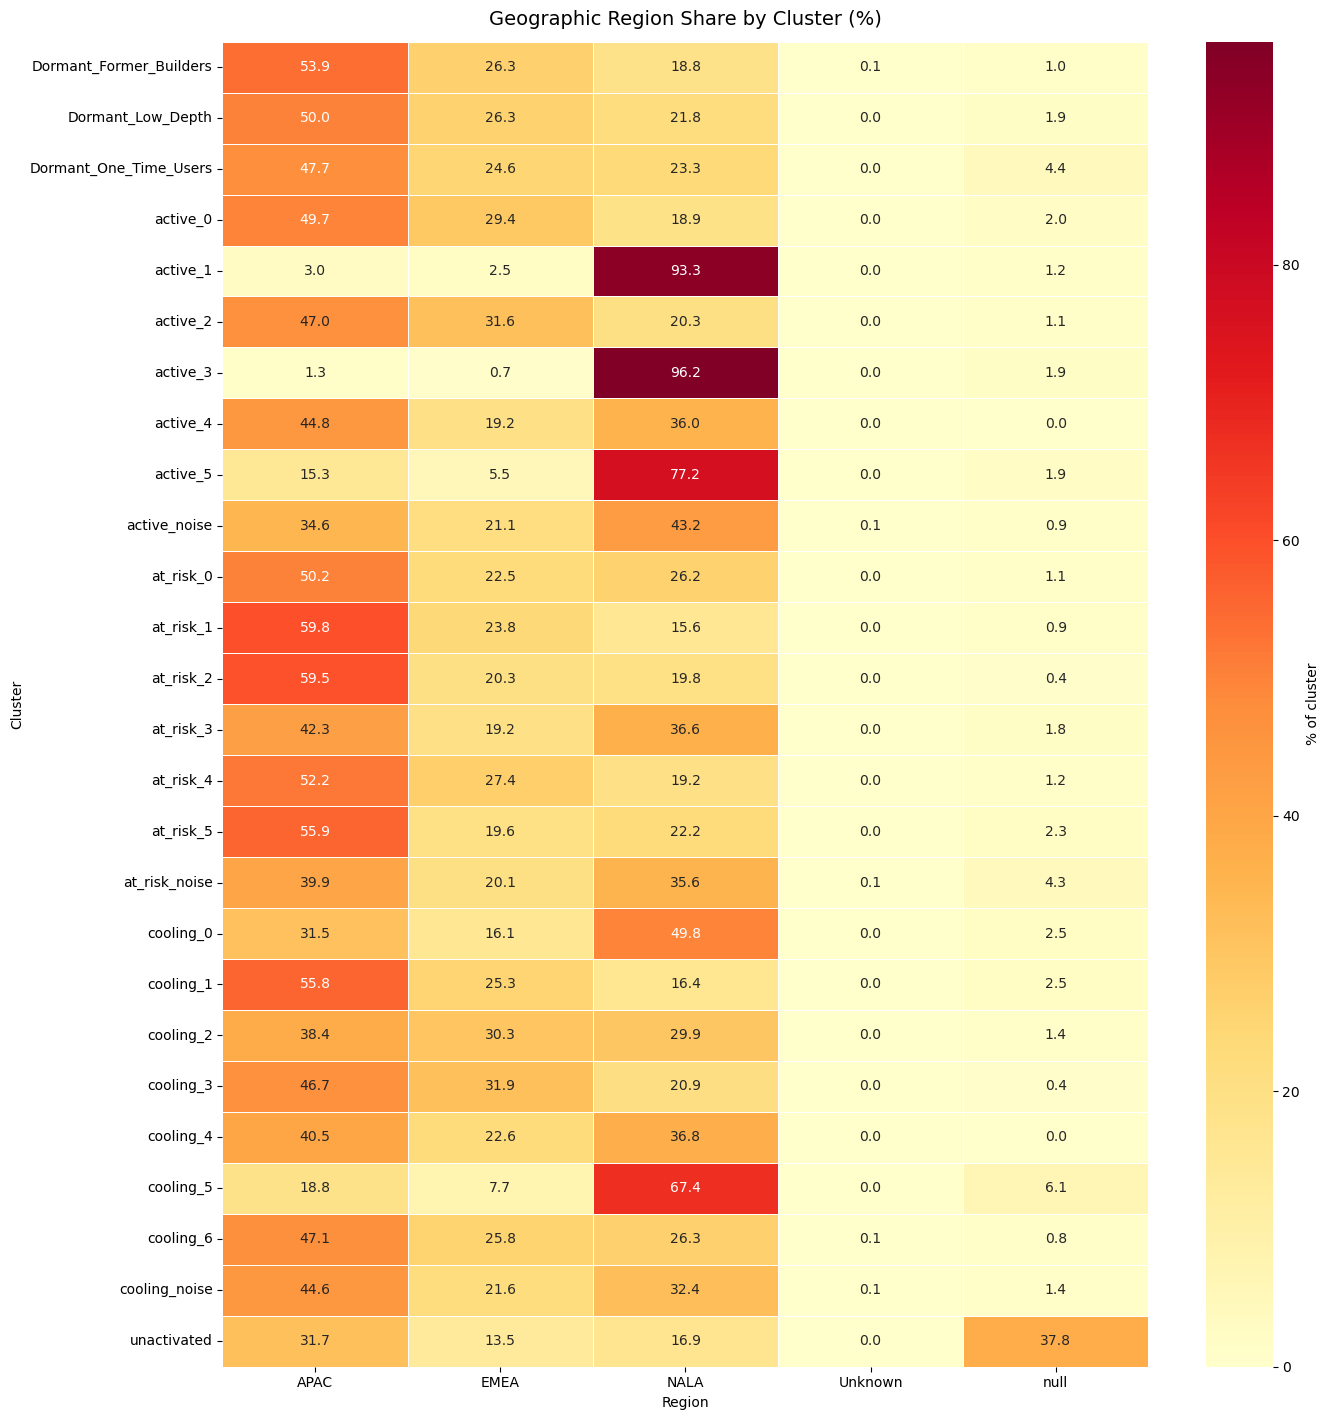

Saved → demographic_outputs/fig_01_region_heatmap.png


In [7]:
# ── Heatmap: region share by cluster ──────────────────────────────────────────
pivot = region_by_cluster.pivot_table(
    index="cluster_key", columns="region", values="pct_within_cluster", aggfunc="sum"
).fillna(0)

# Drop Unknown column for cleanliness if desired
fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.55)))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.4,
    cbar_kws={"label": "% of cluster"}, ax=ax
)
ax.set_title("Geographic Region Share by Cluster (%)", fontsize=14, pad=12)
ax.set_xlabel("Region")
ax.set_ylabel("Cluster")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_01_region_heatmap.png", dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/fig_01_region_heatmap.png")

## 5. Industry Vertical Distribution by Cluster

In [8]:
industry_by_cluster = con.execute("""
    SELECT
        cluster_key,
        stratum,
        COALESCE(industry_vertical, 'Unknown') AS industry_vertical,
        COUNT(*) AS n_developers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_key), 2) AS pct_within_cluster,
        ROW_NUMBER() OVER (PARTITION BY cluster_key ORDER BY COUNT(*) DESC) AS industry_rank
    FROM cluster_demo
    GROUP BY cluster_key, stratum, industry_vertical
    QUALIFY industry_rank <= 8
    ORDER BY cluster_key, industry_rank
""").fetchdf()

industry_by_cluster.to_csv(OUTPUT_DIR / "03_industry_by_cluster.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/03_industry_by_cluster.csv")
display(industry_by_cluster)

Saved → demographic_outputs/03_industry_by_cluster.csv


,cluster_key,stratum,industry_vertical,n_developers,pct_within_cluster,industry_rank
0,Dormant_Former_Builders,dormant,Other,600873,36.14,1
1,Dormant_Former_Builders,dormant,Academia / Education,275804,16.59,2
2,Dormant_Former_Builders,dormant,Gaming,166848,10.03,3
3,Dormant_Former_Builders,dormant,AEC,114509,6.89,4
4,Dormant_Former_Builders,dormant,Aerospace,61713,3.71,5
...,...,...,...,...,...,...
203,unactivated,unactivated,Gaming,38029,2.21,4
204,unactivated,unactivated,Cloud Services,36954,2.15,5
205,unactivated,unactivated,Media & Entertainment,36158,2.10,6
206,unactivated,unactivated,Financial Services,35995,2.09,7


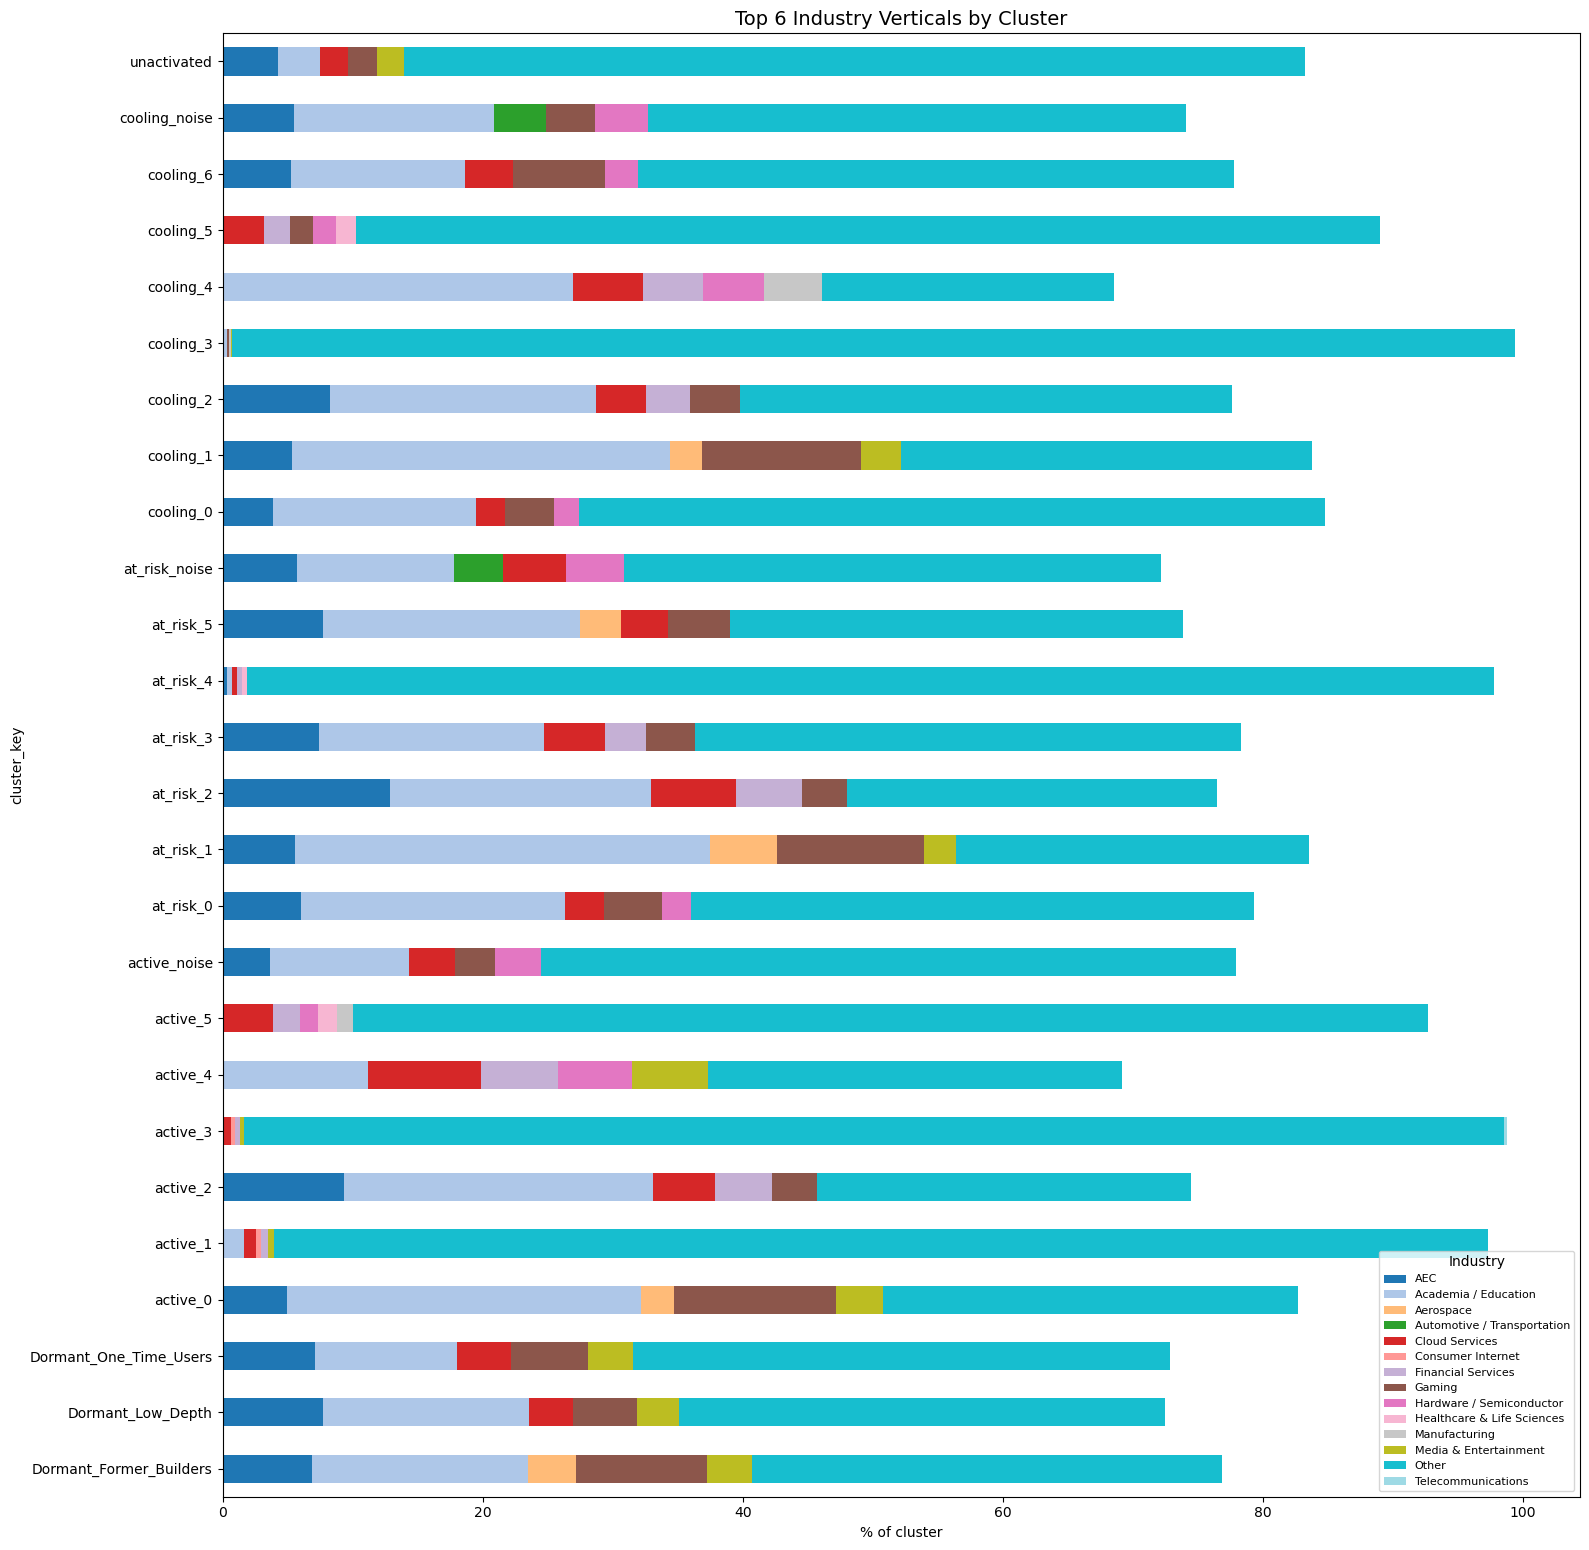

Saved → demographic_outputs/fig_02_industry_stacked_bar.png


In [9]:
# ── Stacked bar: top 6 industries per cluster ─────────────────────────────────
TOP_N = 6
top_industries = (
    industry_by_cluster[industry_by_cluster["industry_rank"] <= TOP_N]
    .pivot_table(index="cluster_key", columns="industry_vertical",
                 values="pct_within_cluster", aggfunc="sum")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(16, max(6, len(top_industries) * 0.6)))
top_industries.plot(kind="barh", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("% of cluster")
ax.set_title(f"Top {TOP_N} Industry Verticals by Cluster", fontsize=14)
ax.legend(loc="lower right", fontsize=8, title="Industry")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_02_industry_stacked_bar.png", dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/fig_02_industry_stacked_bar.png")

## 6. Development Areas by Cluster

`development_areas` is a semicolon-separated multi-value field. We explode it to count individual tags per cluster.

In [10]:
# Pull the raw field and explode in pandas
dev_areas_raw = con.execute("""
    SELECT cluster_key, stratum, development_areas
    FROM cluster_demo
    WHERE development_areas IS NOT NULL AND development_areas != ''
""").fetchdf()

dev_areas_raw["area"] = dev_areas_raw["development_areas"].str.split(";")
dev_areas_exploded = dev_areas_raw.explode("area")
dev_areas_exploded["area"] = dev_areas_exploded["area"].str.strip()

dev_areas_counts = (
    dev_areas_exploded
    .groupby(["cluster_key", "stratum", "area"])
    .size()
    .reset_index(name="n_developers")
)

# Add % within cluster (based on total cluster size, not just those with areas)
cluster_sizes = cluster_summary.set_index("cluster_key")["n_developers"]
dev_areas_counts["pct_of_cluster"] = (
    dev_areas_counts.apply(
        lambda r: round(r["n_developers"] * 100 / cluster_sizes.get(r["cluster_key"], 1), 2), axis=1
    )
)

dev_areas_counts["area_rank"] = (
    dev_areas_counts
    .groupby("cluster_key")["n_developers"]
    .rank(ascending=False, method="first")
    .astype(int)
)

top_dev_areas = dev_areas_counts[dev_areas_counts["area_rank"] <= 10].sort_values(
    ["cluster_key", "area_rank"]
)

top_dev_areas.to_csv(OUTPUT_DIR / "04_development_areas_by_cluster.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/04_development_areas_by_cluster.csv")
display(top_dev_areas)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved → demographic_outputs/04_development_areas_by_cluster.csv


,cluster_key,stratum,area,n_developers,pct_of_cluster,area_rank
2,Dormant_Former_Builders,dormant,Computer Vision / Video Analytics,569083,34.22,1
5,Dormant_Former_Builders,dormant,Data Science,504102,30.32,2
14,Dormant_Former_Builders,dormant,conversational_ai,384827,23.14,3
3,Dormant_Former_Builders,dormant,Content Creation / Rendering,360521,21.68,4
12,Dormant_Former_Builders,dormant,Simulation / Modeling / Design,345723,20.79,5
...,...,...,...,...,...,...
464,unactivated,unactivated,conversational_ai,118657,6.89,6
454,unactivated,unactivated,Data Center / Cloud,117649,6.84,7
450,unactivated,unactivated,AR / VR,106996,6.22,8
453,unactivated,unactivated,Content Creation / Rendering,101826,5.92,9


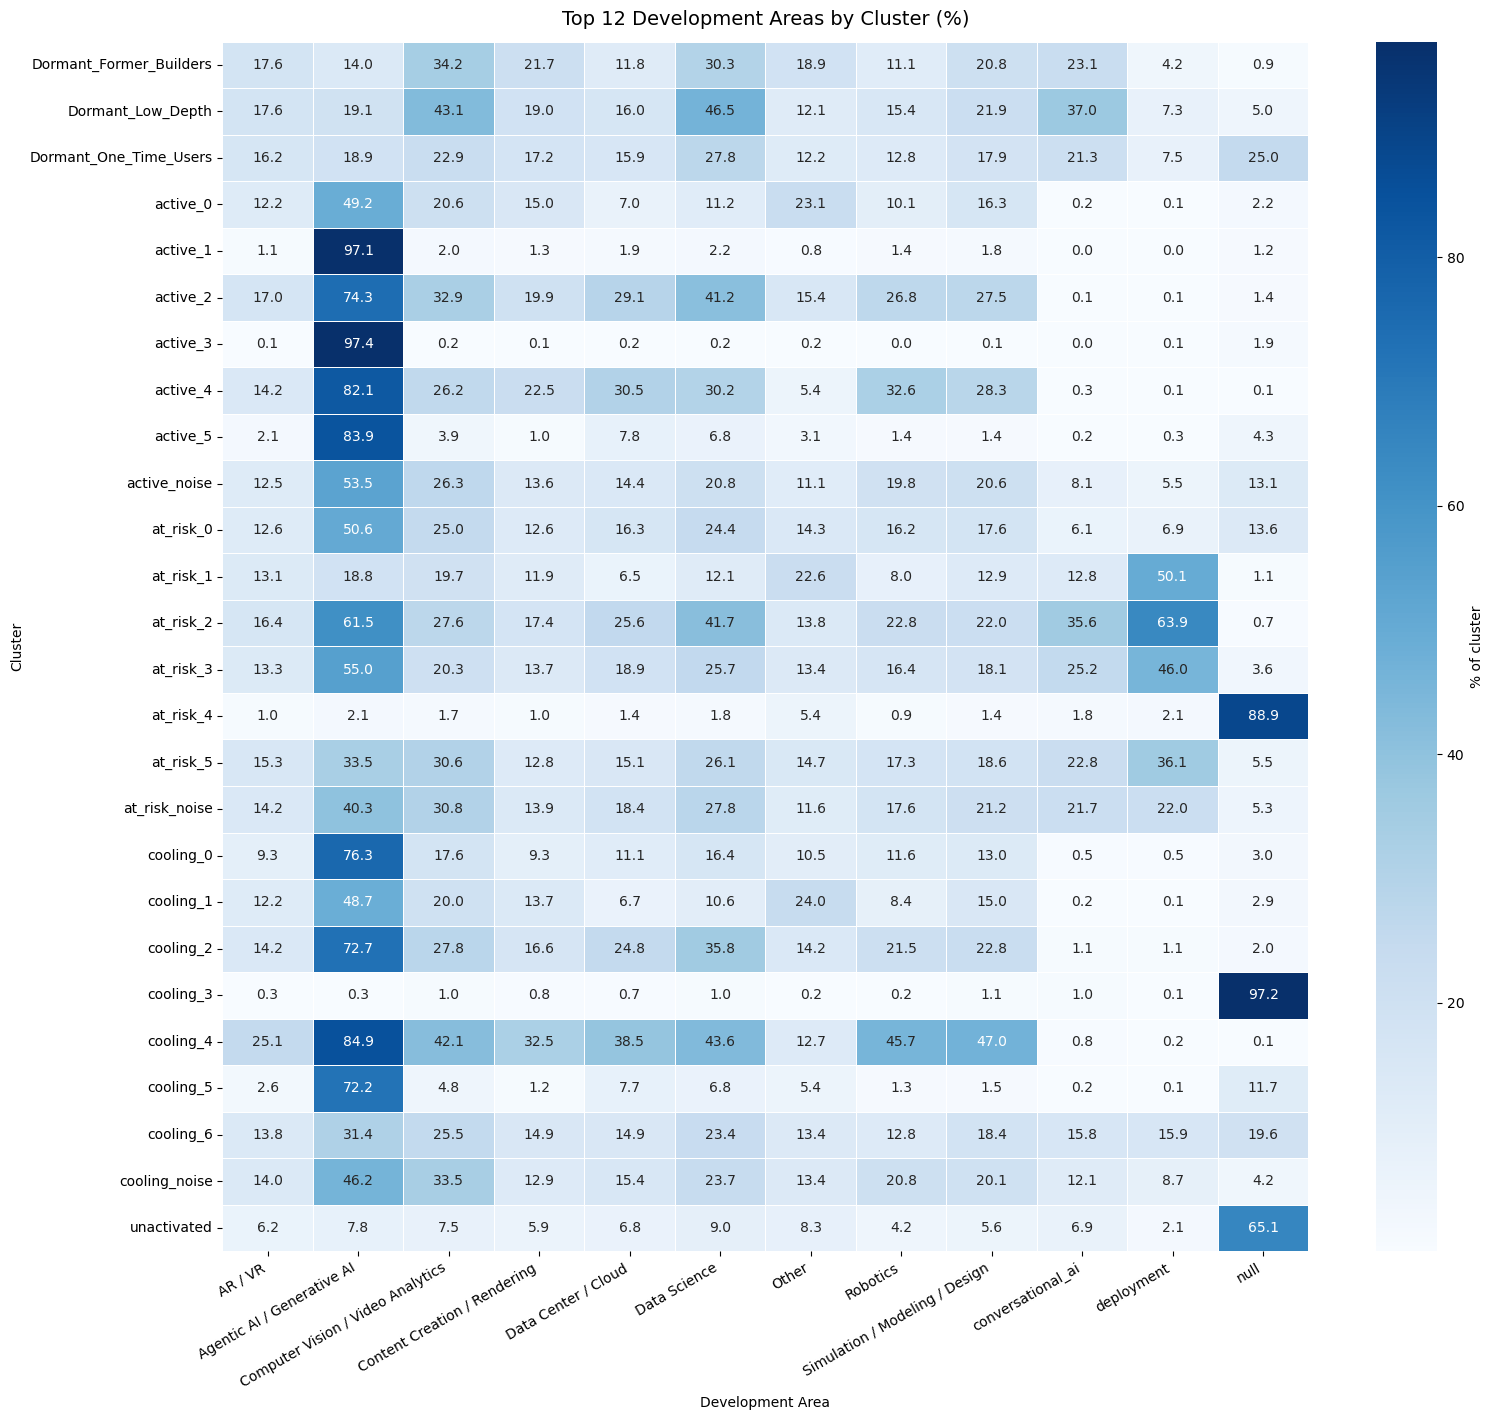

Saved → demographic_outputs/fig_03_dev_areas_heatmap.png


In [11]:
# ── Heatmap: top development area share by cluster ────────────────────────────
TOP_AREAS = 12
global_top_areas = (
    dev_areas_counts
    .groupby("area")["n_developers"].sum()
    .nlargest(TOP_AREAS).index.tolist()
)

pivot_areas = (
    dev_areas_counts[dev_areas_counts["area"].isin(global_top_areas)]
    .pivot_table(index="cluster_key", columns="area",
                 values="pct_of_cluster", aggfunc="sum")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(16, max(6, len(pivot_areas) * 0.55)))
sns.heatmap(
    pivot_areas, annot=True, fmt=".1f", cmap="Blues", linewidths=0.4,
    cbar_kws={"label": "% of cluster"}, ax=ax
)
ax.set_title(f"Top {TOP_AREAS} Development Areas by Cluster (%)", fontsize=14, pad=12)
ax.set_ylabel("Cluster")
ax.set_xlabel("Development Area")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_03_dev_areas_heatmap.png", dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/fig_03_dev_areas_heatmap.png")

## 7. Program Application Source by Cluster

Shows how developers in each cluster joined the program (DLI, DevZone, etc.).

In [12]:
app_source = con.execute("""
    SELECT
        cluster_key,
        stratum,
        COALESCE(program_application_source, 'Unknown') AS program_source,
        COUNT(*) AS n_developers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_key), 2) AS pct_within_cluster
    FROM cluster_demo
    GROUP BY cluster_key, stratum, program_application_source
    ORDER BY cluster_key, n_developers DESC
""").fetchdf()

app_source.to_csv(OUTPUT_DIR / "05_program_source_by_cluster.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/05_program_source_by_cluster.csv")
display(app_source)

Saved → demographic_outputs/05_program_source_by_cluster.csv


,cluster_key,stratum,program_source,n_developers,pct_within_cluster
0,Dormant_Former_Builders,dormant,devzone,819734,49.30
1,Dormant_Former_Builders,dormant,null,672161,40.42
2,Dormant_Former_Builders,dormant,Unknown,157738,9.49
3,Dormant_Former_Builders,dormant,dli,4021,0.24
4,Dormant_Former_Builders,dormant,gtc,3361,0.20
...,...,...,...,...,...
333,unactivated,unactivated,dli,452,0.03
334,unactivated,unactivated,brev,74,0.00
335,unactivated,unactivated,nod,20,0.00
336,unactivated,unactivated,hwg,14,0.00


## 8. Account Type by Cluster

Enterprise vs. SMB vs. other account types.

In [13]:
acct_type = con.execute("""
    SELECT
        cluster_key,
        stratum,
        COALESCE(account_type, 'Unknown') AS account_type,
        COUNT(*) AS n_developers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_key), 2) AS pct_within_cluster
    FROM cluster_demo
    GROUP BY cluster_key, stratum, account_type
    ORDER BY cluster_key, n_developers DESC
""").fetchdf()

acct_type.to_csv(OUTPUT_DIR / "06_account_type_by_cluster.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/06_account_type_by_cluster.csv")
display(acct_type)

Saved → demographic_outputs/06_account_type_by_cluster.csv


,cluster_key,stratum,account_type,n_developers,pct_within_cluster
0,Dormant_Former_Builders,dormant,Unknown,1010771,60.79
1,Dormant_Former_Builders,dormant,University,495147,29.78
2,Dormant_Former_Builders,dormant,Enterprise,101092,6.08
3,Dormant_Former_Builders,dormant,Startup,45699,2.75
4,Dormant_Former_Builders,dormant,Enterprise;University,4172,0.25
...,...,...,...,...,...
174,unactivated,unactivated,University,123019,7.15
175,unactivated,unactivated,Startup,15945,0.93
176,unactivated,unactivated,Enterprise;Startup,1398,0.08
177,unactivated,unactivated,Enterprise;University,1265,0.07


## 9. WWFO Category & Target List by Cluster

Strategic Nvidia sales segmentation breakdown per cluster.

In [14]:
wwfo = con.execute("""
    SELECT
        cluster_key,
        stratum,
        COALESCE(wwfo_category, 'Unknown') AS wwfo_category,
        COUNT(*) AS n_developers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_key), 2) AS pct_within_cluster
    FROM cluster_demo
    GROUP BY cluster_key, stratum, wwfo_category
    ORDER BY cluster_key, n_developers DESC
""").fetchdf()

wwfo.to_csv(OUTPUT_DIR / "07_wwfo_by_cluster.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/07_wwfo_by_cluster.csv")
display(wwfo)

Saved → demographic_outputs/07_wwfo_by_cluster.csv


,cluster_key,stratum,wwfo_category,n_developers,pct_within_cluster
0,Dormant_Former_Builders,dormant,null,1182470,71.11
1,Dormant_Former_Builders,dormant,Higher Ed/Research,305503,18.37
2,Dormant_Former_Builders,dormant,Unknown,134750,8.10
3,Dormant_Former_Builders,dormant,Strategic Hyperscale,8620,0.52
4,Dormant_Former_Builders,dormant,Manufacturing,8140,0.49
...,...,...,...,...,...
431,unactivated,unactivated,Oil & Gas/Energy,69,0.00
432,unactivated,unactivated,Media/Entertainment,45,0.00
433,unactivated,unactivated,Other,34,0.00
434,unactivated,unactivated,Logistics & Transportation,15,0.00


## 10. Full Cluster Demographic Profile Summary

One row per cluster with the **dominant** value for each demographic dimension — the single most useful table to hand to the Recommendations team.

In [15]:
full_profile = con.execute("""
    WITH cluster_counts AS (
        SELECT cluster_key, stratum, adoption_direction, COUNT(*) AS n_total
        FROM cluster_demo
        GROUP BY cluster_key, stratum, adoption_direction
    ),
    dom_region AS (
        SELECT cluster_key,
               FIRST(region ORDER BY cnt DESC) AS dominant_region,
               ROUND(MAX(cnt) * 100.0 / SUM(cnt), 1) AS dominant_region_pct
        FROM (
            SELECT cluster_key, COALESCE(region,'Unknown') AS region, COUNT(*) AS cnt
            FROM cluster_demo GROUP BY cluster_key, region
        ) GROUP BY cluster_key
    ),
    dom_country AS (
        SELECT cluster_key,
               FIRST(country ORDER BY cnt DESC) AS dominant_country,
               ROUND(MAX(cnt) * 100.0 / SUM(cnt), 1) AS dominant_country_pct
        FROM (
            SELECT cluster_key, COALESCE(country,'Unknown') AS country, COUNT(*) AS cnt
            FROM cluster_demo GROUP BY cluster_key, country
        ) GROUP BY cluster_key
    ),
    dom_industry AS (
        SELECT cluster_key,
               FIRST(industry_vertical ORDER BY cnt DESC) AS dominant_industry,
               ROUND(MAX(cnt) * 100.0 / SUM(cnt), 1) AS dominant_industry_pct
        FROM (
            SELECT cluster_key, COALESCE(industry_vertical,'Unknown') AS industry_vertical, COUNT(*) AS cnt
            FROM cluster_demo GROUP BY cluster_key, industry_vertical
        ) GROUP BY cluster_key
    ),
    dom_source AS (
        SELECT cluster_key,
               FIRST(program_application_source ORDER BY cnt DESC) AS dominant_program_source
        FROM (
            SELECT cluster_key, COALESCE(program_application_source,'Unknown') AS program_application_source, COUNT(*) AS cnt
            FROM cluster_demo GROUP BY cluster_key, program_application_source
        ) GROUP BY cluster_key
    ),
    dom_acct AS (
        SELECT cluster_key,
               FIRST(account_type ORDER BY cnt DESC) AS dominant_account_type
        FROM (
            SELECT cluster_key, COALESCE(account_type,'Unknown') AS account_type, COUNT(*) AS cnt
            FROM cluster_demo GROUP BY cluster_key, account_type
        ) GROUP BY cluster_key
    )
    SELECT
        cc.cluster_key,
        cc.stratum,
        cc.adoption_direction,
        cc.n_total                       AS n_developers,
        dr.dominant_region,
        dr.dominant_region_pct,
        dc.dominant_country,
        dc.dominant_country_pct,
        di.dominant_industry,
        di.dominant_industry_pct,
        ds.dominant_program_source,
        da.dominant_account_type
    FROM cluster_counts cc
    LEFT JOIN dom_region  dr ON cc.cluster_key = dr.cluster_key
    LEFT JOIN dom_country dc ON cc.cluster_key = dc.cluster_key
    LEFT JOIN dom_industry di ON cc.cluster_key = di.cluster_key
    LEFT JOIN dom_source  ds ON cc.cluster_key = ds.cluster_key
    LEFT JOIN dom_acct    da ON cc.cluster_key = da.cluster_key
    ORDER BY n_developers DESC
""").fetchdf()

display(full_profile)
full_profile.to_csv(OUTPUT_DIR / "08_full_cluster_demographic_profile.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/08_full_cluster_demographic_profile.csv")

,cluster_key,stratum,adoption_direction,n_developers,dominant_region,dominant_region_pct,dominant_country,dominant_country_pct,dominant_industry,dominant_industry_pct,dominant_program_source,dominant_account_type
0,Dormant_Low_Depth,dormant,steady_inactive,2466341,APAC,50.0,China,19.4,Other,37.4,null,Unknown
1,unactivated,unactivated,not_activated,1721230,null,37.8,null,37.8,Other,69.3,null,Unknown
2,Dormant_Former_Builders,dormant,steady_inactive,1662813,APAC,53.9,China,26.7,Other,36.1,devzone,Unknown
3,Dormant_One_Time_Users,dormant,steady_inactive,1175698,APAC,47.7,India,18.2,Other,41.3,null,Unknown
4,at_risk_0,at_risk,at_risk,436295,APAC,50.2,United States,21.0,Other,43.2,devzone,Unknown
5,at_risk_5,at_risk,at_risk,365945,APAC,55.9,China,24.9,Other,34.9,devzone,Unknown
6,at_risk_2,at_risk,at_risk,210377,APAC,59.5,India,40.8,Other,28.4,dli,Unknown
7,at_risk_3,at_risk,at_risk,206907,APAC,42.3,United States,31.8,Other,42.0,devzone,Unknown
8,active_5,active,accelerating_or_active,155026,NALA,77.2,United States,75.6,Other,82.6,api_catalog,Unknown
9,at_risk_1,at_risk,at_risk,145077,APAC,59.7,China,35.9,Academia / Education,31.9,devzone,Unknown


Saved → demographic_outputs/08_full_cluster_demographic_profile.csv


## 11. Export All Results to Excel (One File for Recommendations Team)

In [16]:
excel_path = OUTPUT_DIR / "demographic_analysis_for_recommendations_team.xlsx"

sheets = {
    "Cluster Summary":        cluster_summary,
    "Full Profile (1-row)": full_profile,
    "Region by Cluster":      region_by_cluster,
    "Top Countries":          top_countries,
    "Industry by Cluster":    industry_by_cluster,
    "Dev Areas by Cluster":   top_dev_areas,
    "Program Source":         app_source,
    "Account Type":           acct_type,
    "WWFO Category":          wwfo,
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in sheets.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Excel report saved → {excel_path}")
print("\nSheets included:")
for s in sheets:
    print(f"  • {s}")

Excel report saved → demographic_outputs\demographic_analysis_for_recommendations_team.xlsx

Sheets included:
  • Cluster Summary
  • Full Profile (1-row)
  • Region by Cluster
  • Top Countries
  • Industry by Cluster
  • Dev Areas by Cluster
  • Program Source
  • Account Type
  • WWFO Category


## 12. Save cluster_demo Back to DuckDB (Optional)

Persist the joined table so the Recommendations team can query it directly from the database.

In [17]:
# cluster_demo is already in DuckDB from step 2 — this just confirms it's persisted
n = con.execute("SELECT COUNT(*) FROM cluster_demo").fetchone()[0]
print(f"Table 'cluster_demo' is in DuckDB with {n:,} rows.")
print("The Recommendations team can connect to developer_project.duckdb and query cluster_demo directly.")

con.close()
print("\nDone. All outputs saved to:", OUTPUT_DIR.resolve())

Table 'cluster_demo' is in DuckDB with 9,381,508 rows.
The Recommendations team can connect to developer_project.duckdb and query cluster_demo directly.

Done. All outputs saved to: C:\Users\tyler\OneDrive\Desktop\MSBA\Nvidia Industry Project\Spring2026_IndustryProject\demographic_outputs
